In [1]:
import numpy as np
import pandas as pd
import statistics
import seaborn as sns
import os
import subprocess
import shutil
import plotly.express as px
import sys
sys.path.append('/gpfs/commons/home/mgarbulowski/homic_package/src') 
from homic import file_readers, kraken2, process_data, make_plots
from collections import Counter
from scipy import stats
import matplotlib.pyplot as plt

homic package imported


In [2]:
# define paths
path = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/Metagenomes"
db_path = "/gpfs/commons/home/mgarbulowski/016_proj_shm/ref_dbs/hs_wgs"

# samples id 
all_samps = ["KP005", "KP012", "KP013", "KP016", "KP024", "KP025", "KP026", "KP027", "KP029","KP033","KP035","KP038","KP040","KP046","KP047","KP048"]

## loading metadata
meta = pd.read_csv("/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/metadata_kp.csv")
meta = meta.loc[meta['id'].isin(all_samps)] # keep only the sequenced ones

# intersecting with previous work
path1 = "/gpfs/commons/home/mgarbulowski/homic_package/files/65sp.txt"

with open(path1, "r") as f:
    bl_65sp = [line.strip() for line in f if line.strip()]
bl_65sp = [s.replace('[','').replace(']','') for s in bl_65sp]

# genera
gsg = bl_65sp
gsg = set([s.split()[0] for s in gsg])

In [3]:
### female ###
meta_f = meta.loc[meta['female'] == 1]
samps_ids = meta_f["id"]
path_blast = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/blast_nt_top5/"

fbc01, fbc005, fbc001, df_merged_f = process_data.select_taxa(path_blast, samps_ids, taxa_level="species")

### male ###
meta_m = meta.loc[meta['female'] == 0]
samps_ids = meta_m["id"]
path_blast = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/blast_nt_top5/"
mbc01, mbc005, mbc001, df_merged_m = process_data.select_taxa(path_blast, samps_ids, taxa_level="species")


In [4]:
# female
print("female")
print("0.1%")
print(len(fbc01))
print("")
print("0.05%")
print(len(fbc005))
print("")
print("0.01%")
print(len(fbc001))

# male
print("")
print("male")
print("0.1%")
print(len(mbc01))
print("")
print("0.05%")
print(len(mbc005))
print("")
print("0.01%")
print(len(mbc001))

# (>0.1%, >0.05% and >0.01% corresponding to 65, 121 and 419 species, respectively)

female
0.1%
88

0.05%
113

0.01%
202

male
0.1%
78

0.05%
105

0.01%
203


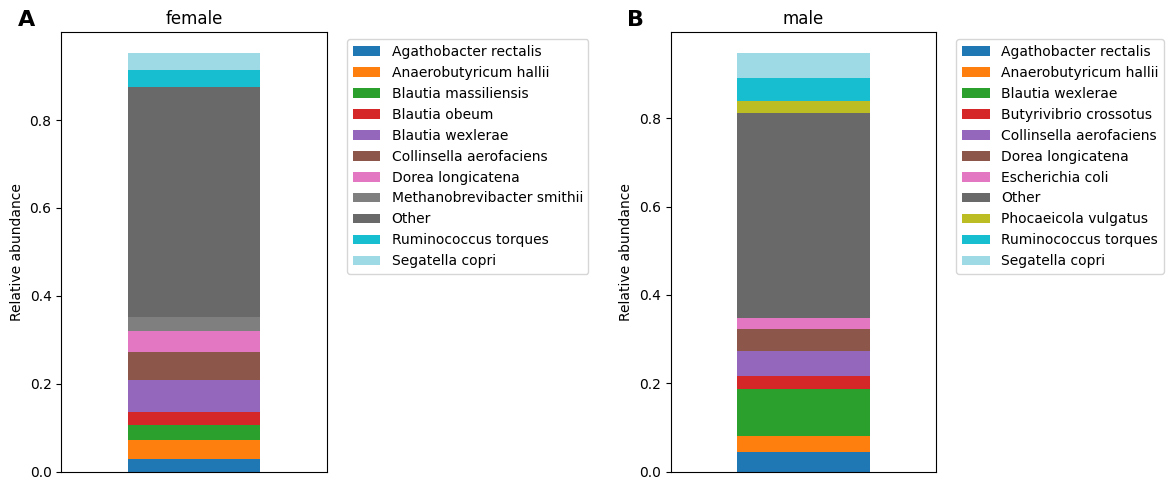

common species with previous work (female): 
38% overlap

common species with previous work (male): 
38% overlap


In [5]:
ntop = 10
## species level female
vals_f = fbc01.values.tolist()
inds_f = fbc01.index.tolist()
inds_f2 = [name if val >= vals_f[ntop-1] else "Other" for name, val in zip(inds_f, vals_f)]

df_s_f = pd.DataFrame({'abundance': vals_f},
                  index=inds_f2)

## species level female
vals_m = mbc01.values.tolist()
inds_m = mbc01.index.tolist()
inds_m2 = [name if val >= vals_m[ntop-1] else "Other" for name, val in zip(inds_m, vals_m)]

df_s_m = pd.DataFrame({'abundance': vals_m},
                  index=inds_m2)

df_s_f = df_s_f.groupby(df_s_f.index).sum()
df_s_m = df_s_m.groupby(df_s_m.index).sum()

fig = make_plots.relative_abundance_double(df_s_f, df_s_m,"female","male")
fig.savefig("/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/figs/relative_abundance_species_malefemale_0.1%_nt.png", dpi=300, bbox_inches='tight')


print("common species with previous work (female): ")
print(str(round(len(list(set(inds_f).intersection(bl_65sp)))/len(bl_65sp) * 100)) + "%" + " overlap")
print("")
print("common species with previous work (male): ")
print(str(round(len(list(set(inds_m).intersection(bl_65sp)))/len(bl_65sp) * 100)) + "%" + " overlap")


Text(0.05, 0.95, 'r = 0.96\np = 4.911e-182')

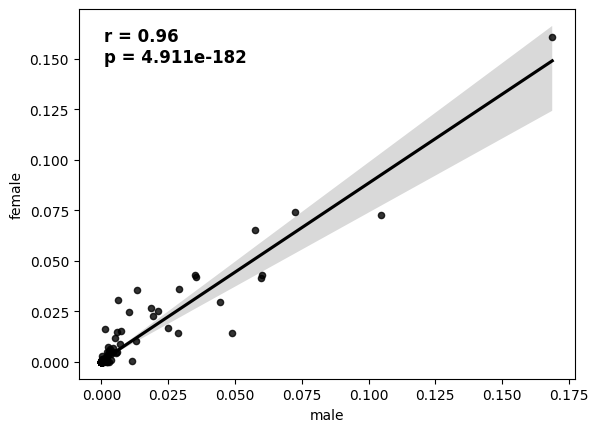

In [6]:
listed_data = [df_merged_m, df_merged_f]
counts = [Counter(df["genus"]) for df in listed_data]
data_names = ["male","female"]
# create DataFrame from all counts
df = pd.DataFrame(counts).fillna(0).astype(int)
df = df.T
df.columns = data_names

df['male']= (df['male']/df['male'].sum()) 
df['female']= (df['female']/df['female'].sum()) 

# 1
g = sns.regplot(x=data_names[0], y=data_names[1], data=df, scatter_kws={'s':20, 'color': 'black'}, line_kws={'color': 'black'})
res = stats.pearsonr(df[data_names[0]], df[data_names[1]])
    
g.text(
    0.05, 0.95,
    f"r = {res[0]:.2f}\n"
    f"p = {res[1]:.3e}",
    transform=g.transAxes,
    ha="left", va="top",
    fontsize=12, weight="bold"
    )

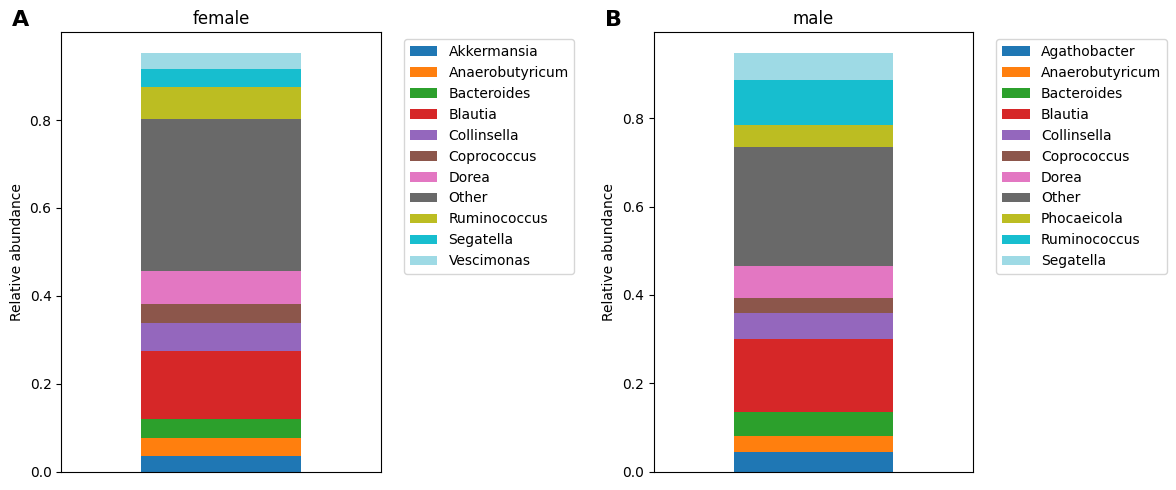

common genera with previous work (male): 
54% overlap
common genera with previous work (female): 
57% overlap


In [7]:
## genus level (based on species)
#female
s1 = fbc01.index.to_list()
s2 = [s.split()[0] for s in s1]

gfbc01 = fbc01.set_axis(s2, axis='index')
gfbc01 = gfbc01.groupby(level=0).sum()
gfbc01 = gfbc01.sort_values(ascending=False)
#male
s1 = mbc01.index.to_list()
s2 = [s.split()[0] for s in s1]

gmbc01 = mbc01.set_axis(s2, axis='index')
gmbc01 = gmbc01.groupby(level=0).sum()
gmbc01 = gmbc01.sort_values(ascending=False)

ntop = 10
## species level female
vals_f = gfbc01.values.tolist()
inds_f = gfbc01.index.tolist()
inds_f2 = [name if val >= vals_f[ntop-1] else "Other" for name, val in zip(inds_f, vals_f)]

df_s_f = pd.DataFrame({'abundance': vals_f},
                  index=inds_f2)

## species level female
vals_m = gmbc01.values.tolist()
inds_m = gmbc01.index.tolist()
inds_m2 = [name if val >= vals_m[ntop-1] else "Other" for name, val in zip(inds_m, vals_m)]

df_s_m = pd.DataFrame({'abundance': vals_m},
                  index=inds_m2)

df_s_f = df_s_f.groupby(df_s_f.index).sum()
df_s_m = df_s_m.groupby(df_s_m.index).sum()

fig = make_plots.relative_abundance_double(df_s_f, df_s_m,"female","male")
fig.savefig("/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/figs/relative_abundance_genus_malefemale_0.1%_nt.png", dpi=300, bbox_inches='tight')

s1 = gmbc01.index.to_list()
s2 = [s.split()[0] for s in s1]
print("common genera with previous work (male): ")
print(str(round(len(list(set(s2).intersection(gsg)))/len(gsg) * 100)) + "%" + " overlap")

print("common genera with previous work (female): ")
s1 = gfbc01.index.to_list()
s2 = [s.split()[0] for s in s1]
print(str(round(len(list(set(s2).intersection(gsg)))/len(gsg) * 100)) + "%" + " overlap")



Text(0.05, 0.95, 'r = 0.96\np = 4.911e-182')

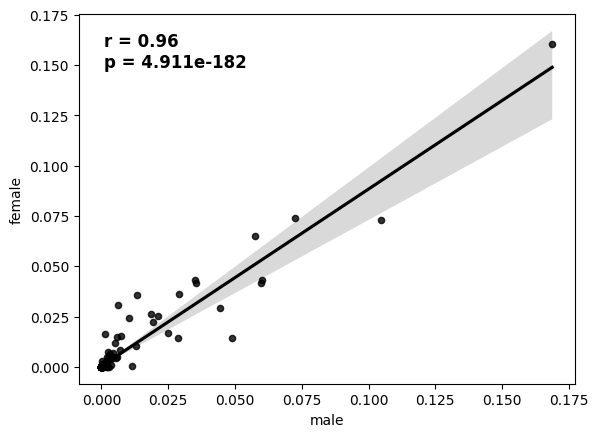

In [8]:
listed_data = [df_merged_m, df_merged_f]
counts = [Counter(df["genus"]) for df in listed_data]
data_names = ["male","female"]
# create DataFrame from all counts
df = pd.DataFrame(counts).fillna(0).astype(int)
df = df.T
df.columns = data_names

df['male']= (df['male']/df['male'].sum()) 
df['female']= (df['female']/df['female'].sum()) 

# 1
g = sns.regplot(x=data_names[0], y=data_names[1], data=df, scatter_kws={'s':20, 'color': 'black'}, line_kws={'color': 'black'})
res = stats.pearsonr(df[data_names[0]], df[data_names[1]])
    
g.text(
    0.05, 0.95,
    f"r = {res[0]:.2f}\n"
    f"p = {res[1]:.3e}",
    transform=g.transAxes,
    ha="left", va="top",
    fontsize=12, weight="bold"
    )

In [9]:
# saturation curve
reads_n = []
spec_n = []
chao1_all = []
for idx, samp in enumerate(all_samps):  
    reads_r1 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/Metagenomes/016-Meta-" + str(idx+1) + "/" + samp + "_S" + str(idx+1) + "_L001_k2_1.fastq"
    reads_r2 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/Metagenomes/016-Meta-" + str(idx+1) + "/" + samp + "_S" + str(idx+1) + "_L001_k2_2.fastq"
    
    tmp_r1 = file_readers.fastq(reads_r1)
    tmp_r2 = file_readers.fastq(reads_r2)
    reads_n.append(len(tmp_r1[0]) + len(tmp_r2[0]))
    
    path_blast = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/blast_nt_top5/" + samp + "_blastn_report.txt"
    df = process_data.read_n_clean_blastn(path_blast, top_hits = True, drop_sp = True)
    chao1 = process_data.chao_idx(df["species"]) # m = 2, as pairwise 
    chao1_all.append(chao1[0])
    spec_n.append(df.shape[0])
    print(idx)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15


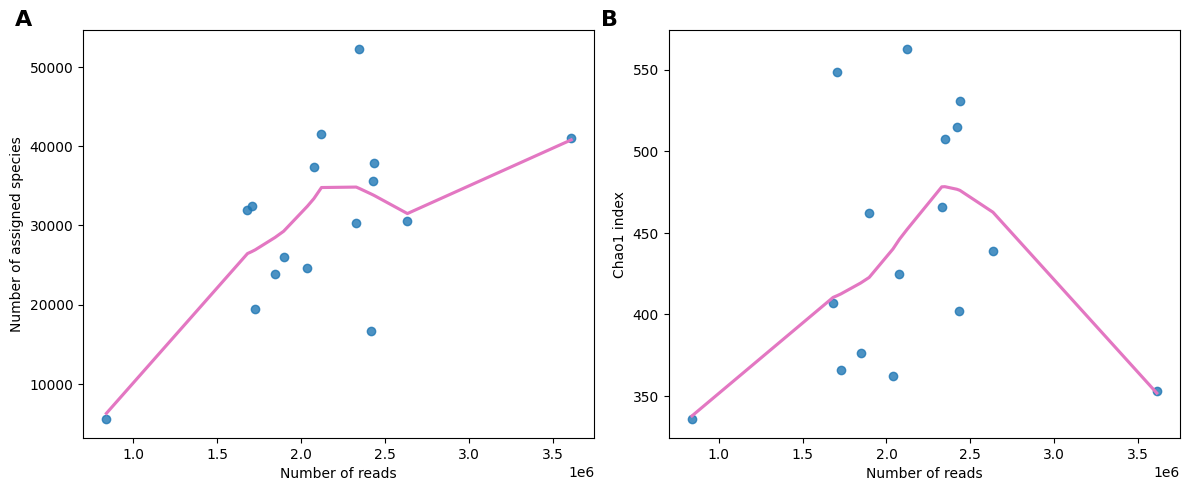

In [11]:
data = {
  "Number of reads": reads_n,
  "Number of assigned species": spec_n,
  "Chao1 index": chao1_all,
}
#load data into a DataFrame object:
df = pd.DataFrame(data)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(x="Number of reads", y="Number of assigned species", data=df,
           lowess=True, line_kws={"color": "C6"}, ax=axes[0]);
sns.regplot(x="Number of reads", y="Chao1 index", data=df,
           lowess=True, line_kws={"color": "C6"}, ax=axes[1]);

axes[0].text(-0.1, 1.05, "A", transform=axes[0].transAxes,
             fontsize=16, fontweight='bold', va='top', ha='right')
axes[1].text(-0.1, 1.05, "B", transform=axes[1].transAxes,
             fontsize=16, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.show()

fig.savefig("/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/figs/saturation_curves_all_samps_nt.png", dpi=300, bbox_inches='tight')